In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Setting Networks

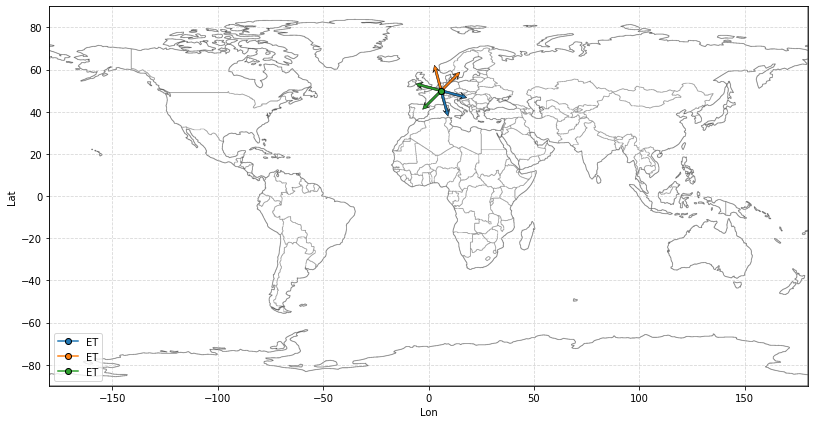

In [2]:
det_ET1 = {'name':'ET','lon':6, 'lat':50, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':6, 'lat':50, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':6, 'lat':50, 'rot':-120, 'shape':60}
detectors = [det_ET1, det_ET2, det_ET3]

fig = gw.draw_detectors(detectors)

### Setting GW Source Propertites

In [3]:
GwPrms = {}                                                                                                
GwPrms['dL'] 	= 10.96
GwPrms['Mc'] 	= 9.57
GwPrms['eta'] 	= 0.25
GwPrms['iota'] 	= 0.52
GwPrms['psi'] 	= 2.32
GwPrms['t_coal'] 	= 0.00
GwPrms['phi_coal'] 	= -1.37
GwPrms['RA'] 	= -135.75
GwPrms['Dec'] 	= 72.92
GwPrms['sz1'] 	= 0.31
GwPrms['sz2'] 	= 0.16

GwPrms['sx1'] 	= 0.00
GwPrms['sy1'] 	= 0.00

GwPrms['sx2'] 	= 0.00
GwPrms['sy2'] 	= 0.00

### Loading Precomputed DALI Tensors

In [4]:
tensors = np.load("DaliTensors.npz")

Fisher = tensors["Fisher"]
Db12   = tensors["Db12"]
Db22   = tensors["Db22"]
Tp13   = tensors["Tp13"]
Tp23   = tensors["Tp23"]
Tp33   = tensors["Tp33"]

Doublet = [Db12, Db22]
Triplet = [Tp13, Tp23, Tp33]

dali_tensors = [Fisher, Doublet, Triplet]

## Running GWDALI (Method = "Fisher")
* It gives the samples obtained via multivariate-normal sampling of the covariance matrix (Fisher inversion) around the GW parameters injections (free parameters).

### The outputs are:
* Results = Samples, Cov, eps
* Tensors = [Fisher, None, None ]
* runtimes = [runtime_tensors, None]

where Cov is the covariance matrix obtained via inversion of the Fisher matrix 

$$Cov \equiv F^{-1}$$

and **eps** is the inversion error defined as:

$$\epsilon \equiv \underset{ij}{max} |(F \cdot Cov - \mathbb{I})_{ij}|$$



In [5]:
FreeParams = ["dL","iota"]

resF = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"], # Free Parameters
					approx = "TaylorF2", # It will not be used if the user provide the 'dali_tensors'
					method = "Fisher", # (Inversion Method)
					inversion_method = "default", # It make use of numpy.linalg.inv() or sicpy.linalg.inv()
					# inversion_method = "pseudo", # It make use os More-Penrose Pseudo Inversion via numpy.linalg.pinv(F,rcond)
					# rcond = 1.e-9, # [Used if inversion_method="pseudo"] Cutoff for small singular values (see https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)
					new_priors = None,
					dali_tensors = dali_tensors,
					plot_signal=False,
					nsamples = 6000, # Points used for numpy.random.multivariate_normal(Truths,Cov)
					remove_out=True, # Remove output path
					verbose = True,
					hide_info = False, # Hide GWDALI informatins
					output_name=f'gwdali_output/'
				)

print("GWDALI (Fisher) concluded!")

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Fisher
 Approx:  TaylorF2 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.981907492411947
ET (2) SNR = 12.676552183767917
ET (3) SNR = 11.52371525738471
Computing Tensors ...

<< DALI tensors loaded by the user >>

tensors loaded successfully!

>> DALI-Tensors OK!
GWDALI (Fisher) concluded!


### Outputs:

In [6]:
Res, Tensors, runtimes = resF

Samples, Cov, eps = Res

print("Fisher x Cov =\n",Fisher @ Cov,'\n' )

print("\n [GWDALI]\n Conditioning Number eps =",eps)

I = np.eye(len(FreeParams)) # Identity Matrix
eps2 = np.max( np.abs(I - Fisher@Cov) )

print("\n [Manual]\n Conditioning Number eps =",eps2)

Fisher x Cov =
 [[ 1.00000000e+00 -2.68392958e-15]
 [-1.62842883e-14  1.00000000e+00]] 


 [GWDALI]
 Conditioning Number eps = 1.765254609153999e-14

 [Manual]
 Conditioning Number eps = 1.765254609153999e-14


### Running GWDALI (Fisher + Gaussian Prior)
* Inversion Method

In [7]:
diagG = [ 1./10**2, 1./np.pi**2 ]
FisherPrior = np.eye(2)*diagG
dali_tensors2 = [Fisher+FisherPrior,Doublet,Triplet]

resG = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"], # Free Parameters
					approx = "TaylorF2", # It will not be used if the user provide the 'dali_tensors'
					method = "Fisher", # (Inversion Method)
					inversion_method = "default", # It make use of numpy.linalg.inv() or sicpy.linalg.inv()
					# inversion_method = "pseudo", # It make use os More-Penrose Pseudo Inversion via numpy.linalg.pinv(F,rcond)
					# rcond = 1.e-9, # [Used if inversion_method="pseudo"] Cutoff for small singular values (see https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)
					new_priors = None,
					dali_tensors = dali_tensors2,
					plot_signal=False,
                    nsamples = 6000, # Points used for numpy.random.multivariate_normal(Truths,Cov)
					remove_out=True, # Remove output path
					verbose = True,
					hide_info = False, # Hide GWDALI informatins
					output_name=f'gwdali_output/'
				)

print("GWDALI (Fisher) concluded!")

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Fisher
 Approx:  TaylorF2 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.981907492411947
ET (2) SNR = 12.676552183767917
ET (3) SNR = 11.52371525738471
Computing Tensors ...

<< DALI tensors loaded by the user >>

tensors loaded successfully!

>> DALI-Tensors OK!
GWDALI (Fisher) concluded!


### Running GWDALI (Singlet = Fisher_MCMC)
- Singlet-DALI With Tensors Pre-Computed

In [8]:
resS = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"], # Free Parameters
					approx = "TaylorF2",
					method="Singlet", # (Fisher Sampling Method)
					sampler="nestle",
					dali_tensors = dali_tensors,
					plot_signal=False,
					nlive = 300, # nlive for nested sampling
					remove_out = True, # Remove output path
					verbose = True,
					hide_info = False, # Hide GWDALI informatins
					output_name=f'gwdali_output/'
				)

print("GWDALI (Singlet) concluded!")

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Singlet
 Approx:  TaylorF2 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.981907492411947
ET (2) SNR = 12.676552183767917
ET (3) SNR = 11.52371525738471
Computing Tensors ...

<< DALI tensors loaded by the user >>

tensors loaded successfully!

>> DALI-Tensors OK!


 Running Sampler (nestle)...

it=  1404 logz=-4.246428718
GWDALI (Singlet) concluded!


If the user are interested on using other samplers like (emcee or ptemcee), it can also provide the following parameters (see Bilby documentation: https://bilby-dev.github.io/bilby/samplers.html#):
* nsteps
* nwalkers
* ntemps
* nsamples
* npool
* pos0

### Reading Results

In [9]:
samplesF, Cov1, eps1 = resF[0]
samplesG, Cov2, eps2 = resG[0]
samplesS, priors, likelihood_times, Evidence = resS[0]

### Plotting Results with "getdist"

Removed no burn in
Removed no burn in
Removed no burn in


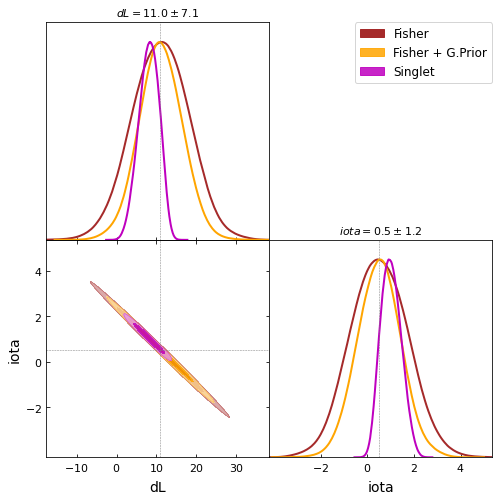

In [10]:
from getdist import MCSamples, plots

samples1 = MCSamples(samples=samplesF, label="Fisher", names=FreeParams)
samples2 = MCSamples(samples=samplesG, label="Fisher + G.Prior", names=FreeParams)
samples3 = MCSamples(samples=samplesS, label="Singlet", names=FreeParams)

g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samples1, samples2,samples3], 
                filled=True,
                title_limit=1,
                markers = {"dL":GwPrms["dL"],
                           "iota":GwPrms["iota"]},
                colors=["brown","orange","m"],
                line_args=[ {"color":"brown","lw":2},
                            {"color":"orange","lw":2},
                            {"color":"m","lw":2}] 
                )